<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Welcome to ZZSC9020

This Python notebook shows how to clone the course GitHub repository on Google Colab.

You can develop your data analysis on Google Colab without downloading the data to your computer.

In [ ]:
# This will remove all user-defined variables from the workspace
%reset -f

In [22]:


# Import any packages
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import plot_tree
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import holidays
# Get NSW public holidays
nsw_holidays = holidays.country_holidays('AU', subdiv='NSW')



In [14]:
import pandas as pd 

# Joint forecastdemand_nsw files into a single file. 
!cat data/NSW/forecastdemand_nsw.csv.zip.part* > data/NSW/forecastdemand_nsw.csv.zip

# Unzip the data files into the data folder
!unzip -o data/NSW/forecastdemand_nsw.csv.zip -d data/NSW
!unzip -o data/NSW/temperature_nsw.csv.zip -d data/NSW
!unzip -o data/NSW/totaldemand_nsw.csv.zip -d data/NSW

# Remove forecastdemand_nsw.csv.zip
!rm data/NSW/forecastdemand_nsw.csv.zip

# the forecastdemand_nsw.csv file
df_forecast = pd.read_csv('data/NSW/forecastdemand_nsw.csv')

# the temperature_nsw.csv file
df_temperature = pd.read_csv('data/NSW/temperature_nsw.csv')

# inspect the totaldemand_nsw.csv file
df_totaldemand = pd.read_csv('data/NSW/totaldemand_nsw.csv')

# delete the unzipped files to save space
!rm data/NSW/forecastdemand_nsw.csv
!rm data/NSW/temperature_nsw.csv
!rm data/NSW/totaldemand_nsw.csv

Archive:  data/NSW/forecastdemand_nsw.csv.zip
  inflating: data/NSW/forecastdemand_nsw.csv  
Archive:  data/NSW/temperature_nsw.csv.zip
  inflating: data/NSW/temperature_nsw.csv  
Archive:  data/NSW/totaldemand_nsw.csv.zip
  inflating: data/NSW/totaldemand_nsw.csv  


In [ ]:
# Convert all to pandas datetime and normalize to day-level
# Convert 'DATETIME' columns to datetime format (auto-infer format)
df_forecast['DATETIME'] = pd.to_datetime(df_forecast['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
df_temperature['DATETIME'] = pd.to_datetime(df_temperature['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
df_totaldemand['DATETIME'] = pd.to_datetime(df_totaldemand['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
# Group forecast by DATETIME and average
df_forecast_avg = df_forecast.groupby('DATETIME', as_index=False)['FORECASTDEMAND'].mean()

# Merge all DataFrames on 'DATETIME'
df_merged = df_forecast_avg.merge(df_totaldemand[['DATETIME', 'TOTALDEMAND']], on='DATETIME', how='left') \
                           .merge(df_temperature[['DATETIME', 'TEMPERATURE']], on='DATETIME', how='left')

# Resample by day and calculate min, max, and mean for TEMPERATURE
# Set 'DATETIME' as index before resampling
df_merged = df_merged.set_index('DATETIME')

df_daily = df_merged.resample('D').agg({
    'TEMPERATURE': ['min', 'max', 'mean'],
    'FORECASTDEMAND': 'mean',
    'TOTALDEMAND': 'mean'
})

print(df_daily.head())


           TEMPERATURE                  FORECASTDEMAND   TOTALDEMAND
                   min   max       mean           mean          mean
DATETIME                                                            
2010-01-01        22.1  28.8  25.185417    7723.688982   7801.352917
2010-01-02        22.2  29.4  24.795833    7804.668591   8017.459792
2010-01-03        17.9  21.5  19.462500    7491.520488   7399.899583
2010-01-04        17.9  23.9  20.847917    8592.014274   8241.720208
2010-01-05        15.4  27.7  22.660417    8907.999454   8827.813125
2010-01-06        20.3  25.6  22.695833    8937.921381   9021.721875
2010-01-07        20.5  23.6  21.879167    8705.842333   8566.847500
2010-01-08        19.7  26.3  23.045833    8914.472452   8926.811042
2010-01-09        18.3  36.3  27.416667    8799.527669   9242.460208
2010-01-10        22.1  29.5  25.297872    8739.841460   9101.040625
2010-01-11        21.7  26.4  23.700000    9632.470392   9584.220000
2010-01-12        23.1  32.0  26.9

In [18]:
from sklearn.metrics import mean_squared_error, r2_score    

# Create binary features for extreme temperature events
df_daily['extreme_hot'] = (df_daily['TEMPERATURE']['max'] > 35).astype(bool)
df_daily['extreme_cold'] = (df_daily['TEMPERATURE']['min'] < 5).astype(bool)

print(df_daily.head())

# Base performance
base_mse = mean_squared_error(df_daily['TOTALDEMAND']['mean'], df_daily['FORECASTDEMAND']['mean'])
base_r2 = r2_score(df_daily['TOTALDEMAND']['mean'], df_daily['FORECASTDEMAND']['mean'])

hot_mask = df_daily['extreme_hot']
cold_mask = df_daily['extreme_cold']
regular_mask = ~(hot_mask | cold_mask)

masks = {
    'Extreme Hot Days': hot_mask,
    'Extreme Cold Days': cold_mask,
    'Regular Days': regular_mask
}

results = {}
for label, mask in masks.items():
    mse = mean_squared_error(df_daily[mask]['TOTALDEMAND']['mean'], df_daily[mask]['FORECASTDEMAND']['mean'])
    r2 = r2_score(df_daily[mask]['TOTALDEMAND']['mean'], df_daily[mask]['FORECASTDEMAND']['mean'])
    results[label] = {'MSE': mse, 'R2': r2}

print('-----------------------------------')
print(f"Base Model - MSE: {base_mse}")
print(f"Base Model - R2: {base_r2}")
print('-----------------------------------')
for label, metrics in results.items():
    print(f"Base Model - {label} MSE: {metrics['MSE']}")
print('-----------------------------------')
for label, metrics in results.items():
    print(f"Base Model - {label} R2: {metrics['R2']}")


           TEMPERATURE                  FORECASTDEMAND  TOTALDEMAND  \
                   min   max       mean           mean         mean   
DATETIME                                                              
2010-01-01        22.1  28.8  25.185417    7723.688982  7801.352917   
2010-01-02        22.2  29.4  24.795833    7804.668591  8017.459792   
2010-01-03        17.9  21.5  19.462500    7491.520488  7399.899583   
2010-01-04        17.9  23.9  20.847917    8592.014274  8241.720208   
2010-01-05        15.4  27.7  22.660417    8907.999454  8827.813125   

           extreme_hot extreme_cold  
                                     
DATETIME                             
2010-01-01       False        False  
2010-01-02       False        False  
2010-01-03       False        False  
2010-01-04       False        False  
2010-01-05       False        False  
-----------------------------------
Base Model - MSE: 19721.40093934488
Base Model - R2: 0.969071333747246
--------------------

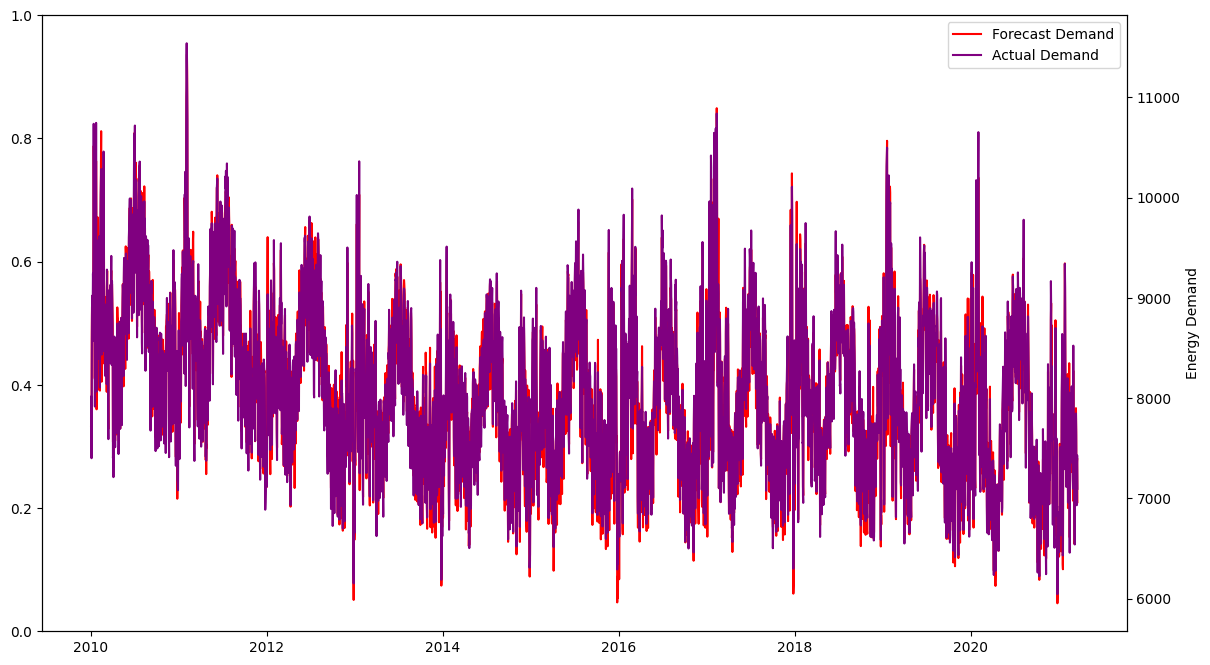

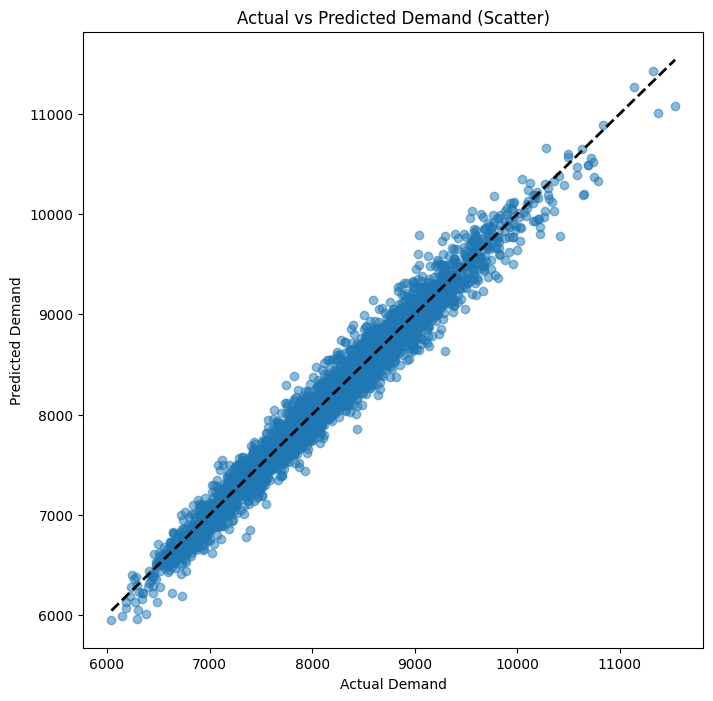

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
ax1 = plt.gca()

# Create right y-axis for demand
ax2 = ax1.twinx()
ax2.plot(df_daily.index, df_daily['FORECASTDEMAND']['mean'], label='Forecast Demand', color='red')
ax2.plot(df_daily.index, df_daily['TOTALDEMAND']['mean'], label='Actual Demand', color='purple')
ax2.set_ylabel('Energy Demand')
ax2.legend(loc='upper right')

# Scatter plot of actual vs predicted
plt.figure(figsize=(8, 8))
plt.scatter(df_daily['TOTALDEMAND']['mean'], df_daily['FORECASTDEMAND']['mean'], alpha=0.5)
plt.plot([df_daily['TOTALDEMAND']['mean'].min(), df_daily['TOTALDEMAND']['mean'].max()], [df_daily['TOTALDEMAND']['mean'].min(), df_daily['TOTALDEMAND']['mean'].max()], 'k--', lw=2)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand (Scatter)')
plt.show()

In [23]:
# Create feature matrix X with multiple columns
X = pd.DataFrame({
    'datetime': df_daily.index,
    'temp_mean': df_daily['TEMPERATURE']['mean'],
    'temp_min': df_daily['TEMPERATURE']['min'],
    'temp_max': df_daily['TEMPERATURE']['max'],
    'extreme_hot': df_daily['extreme_hot'],
    'extreme_cold': df_daily['extreme_cold']
})
# Target variable
y= df_daily['TOTALDEMAND']['mean'].values

# Add day of week and month - feature engineering
X['dayofweek'] = X['datetime'].dt.dayofweek
X['month'] = X['datetime'].dt.month
# Rolling averages (3-day mean temperature)
X['temp_rolling3'] = X['temp_mean'].rolling(window=3, min_periods=1).mean()
X['temp_diff'] = X['temp_mean'] - X['temp_mean'].shift(1)
X['is_holiday'] = X['datetime'].dt.date.apply(lambda x: bool(x in nsw_holidays))

# One-hot encode day of week, month
X = pd.get_dummies(X, columns=['dayofweek', 'month'], drop_first=True)

# Feature matrix X and target y
feature_cols = ['temp_mean', 'temp_min', 'temp_max', 'temp_rolling3', 'temp_diff', 'extreme_hot', 'extreme_cold', 'is_holiday'] + \
               [col for col in X.columns if col.startswith('dayofweek_') or col.startswith('month_')]
X = X[feature_cols].fillna(0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomizedSearchCV for XGBoost
xgb_model = xgb.XGBRegressor()
param_distributions = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [7, 10, 15, 20],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=150,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Best model
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Params:", random_search.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

print('-----------------------------------')

print("XGBoost Model - MSE:", mean_squared_error(y_test, y_pred))
print("XGBoost Model - R2:", r2_score(y_test, y_pred))  
print('-----------------------------------')



Fitting 3 folds for each of 150 candidates, totalling 450 fits
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.3, max_depth=7, n_estimators=200, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.3, max_depth=7, n_estimators=200, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.3, max_depth=7, n_estimators=200, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.1, max_depth=7, n_estimators=300, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.1, max_depth=7, n_estimators=300, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.1, max_depth=7, n_estimators=300, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=   0.4s
[CV] END cols

/Users/liammitrodobson/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.05, max_depth=10, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.05, max_depth=10, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.05, max_depth=10, n_estimators=200, reg_alpha=0.1, reg_lambda=1, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=7, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=7, n_estimators=200, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=7, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=7, n

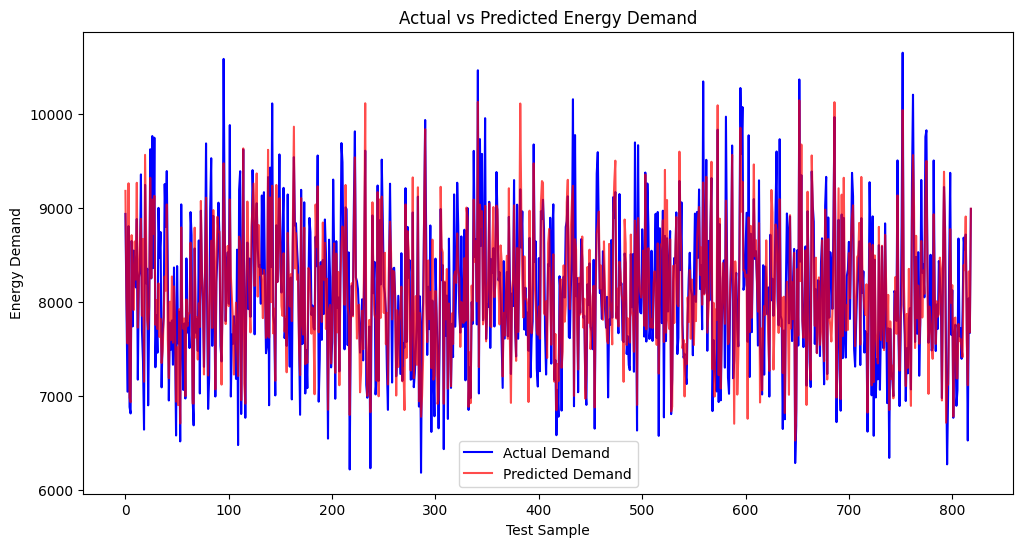

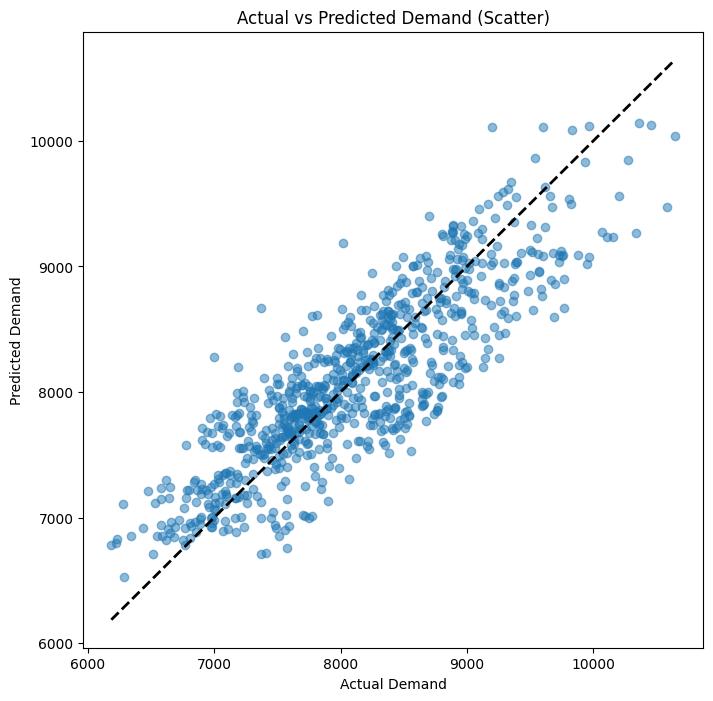

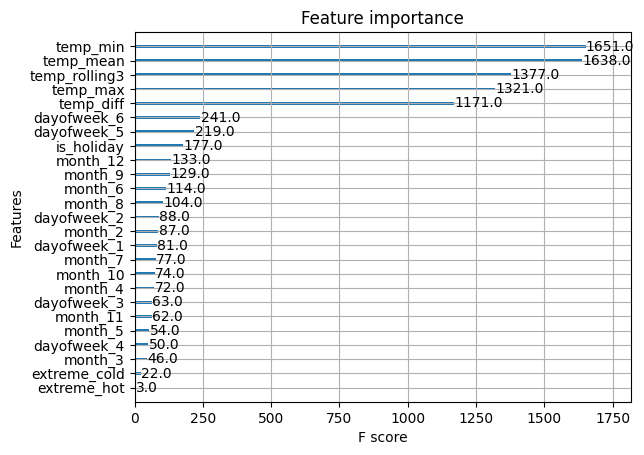

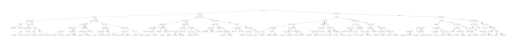

In [24]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Demand', color='blue')
plt.plot(y_pred, label='Predicted Demand', color='red', alpha=0.7)
plt.title('Actual vs Predicted Energy Demand')
plt.xlabel('Test Sample')
plt.ylabel('Energy Demand')
plt.legend()
plt.show()

# Scatter plot of actual vs predicted

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand (Scatter)')
plt.show()

# Feature importance plot
xgb.plot_importance(best_model)
# Tree plot with higher resolution
xgb.plot_tree(best_model, num_trees=0)
plt.savefig("xgboost-plots/xgboost_tree.png", dpi=1200, bbox_inches='tight')
